# Import and Global Param


In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
from discodj.cosmology.neutrinos import get_masses
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

import baccoemu

import camb
from camb import model
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", False) 
import jax.numpy as jnp
#from discoeb.background import evolve_background
#from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched


#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True, 
#})
#
#plt.rcParams.update({
#    'pgf.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',  # Paquets LaTeX supplémentaires
#    'font.family': 'serif',  # Police serif pour correspondre à LaTeX
#    'font.size': 14,
#})

gpu
0.10.2


In [2]:
##### COSMOLOGY #####
cosmo = {
    "h": 0.67,
    "H0": 67,
    "ombh2": 0.049*0.67**2,
    "omch2": 0.269984542*0.67**2,
    "As": 2.215e-09,
    "ns": 0.9619,
    "sum_mnu": 0.3,      # total neutrino mass [eV]
    "tau": 0.0952,
    "w0": -1.0,
    "wa": 0.0,
    "z": 0,
    "Tcmb": 2.7255,
}

h = cosmo["h"]
n_s = cosmo["ns"]
A_s  = cosmo["As"]
z = cosmo["z"]
a = 1.0 / (1.0 + z)
sum_mnu = cosmo["sum_mnu"]

omega_nu = cosmo["sum_mnu"]/(93.14*(h**2))
omega_b = cosmo["ombh2"] / h**2
omega_cdm = cosmo["omch2"] / h**2 
omega_cdm_nu  = cosmo["omch2"] / h**2  - omega_nu
omega_cold = omega_b + omega_cdm
omega_cold_nu = omega_b + omega_cdm_nu

print("Omega_b=",omega_b)
print("Omega_nu=",omega_nu)
print("Omega_cdm=",omega_cdm)
print("Omega_nu+Omega_cdm_nu=",omega_nu+omega_cdm_nu)
print("Omega_m=",omega_cold+omega_nu)

###### Neutrinos masses ######
mnu_massless = [0,0,0]
mnu_deg = [cosmo["sum_mnu"]/3,cosmo["sum_mnu"]/3,cosmo["sum_mnu"]/3] 
m1,m2,m3 = get_masses(2.445e-3,7.60e-5,cosmo["sum_mnu"],'NH')
mnu_NH =[m1,m2,m3]
m1,m2,m3 = get_masses(2.52e-3,7.60e-5,cosmo["sum_mnu"],'IH')
mnu_IH = [m1,m2,m3]

masses = [mnu_deg,mnu_NH,mnu_IH]

print("Degenerate",mnu_deg)
print("NH",mnu_NH)
print("IH",mnu_IH)

# modes to sample
nmodes = 512
kmin = 1e-4
kmax = 4.9
aexp = a
zout = z

#Linear Suppression 
f_nu = omega_nu / (omega_cold+omega_nu)
supp_P = 1-8*f_nu
supp_Pcb = 1-6*f_nu

#k scale
k_h = np.logspace(-4, np.log10(4.9), 600)  # h/Mpc; BACCO nonlinear is used only over this range.
k_check = np.array([1e-3, 1e-2, 1e-1, 1.0])

Omega_b= 0.049
Omega_nu= 0.007175223208039425
Omega_cdm= 0.269984542
Omega_nu+Omega_cdm_nu= 0.269984542
Omega_m= 0.3261597652080394
Degenerate [0.09999999999999999, 0.09999999999999999, 0.09999999999999999]
NH [np.float64(0.09580683814807081), np.float64(0.09620265191734911), np.float64(0.10799050993458006)]
IH [np.float64(0.10410987258393199), np.float64(0.1044742339978741), np.float64(0.09141589341817184)]


# Reference Codes


## BACCO

In [3]:
###########################   MASSLESS   ###########################

bacco_kwargs = dict(
    omega_cold=omega_cold,
    omega_baryon=omega_b,
    A_s=cosmo["As"],
    hubble=h,
    ns=cosmo["ns"],
    neutrino_mass=0,
    w0=cosmo["w0"],
    wa=cosmo["wa"],
    expfactor=a,
    k=k_h,
    cold=True,
)

mp_bacco = baccoemu.Matter_powerspectrum(
    linear=True,
    nonlinear_boost=True,
    baryonic_boost=False,
    verbose=False,
)

# Computation of Linear spectra for massless 
k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)

k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)
pk_ref = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl_ref = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
sigma8 = mp_bacco.get_sigma8(**bacco_kwargs)
print(sigma8)

# Save the Massless Linear
np.savetxt(f"Pk_cb_massless_z{z}_BACCO.txt",np.column_stack([k_h, pk_ref]),header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, massless neutrinos)")

###########################   MASSIVE   ###########################

#Neutrino masses 

#Modify the param for the massive neutrinos

bacco_kwargs['omega_cold'] = omega_cold_nu
bacco_kwargs['neutrino_mass'] = cosmo["sum_mnu"] 

sigma8_nu = mp_bacco.get_sigma8(**bacco_kwargs)
print(sigma8_nu)
# Computation of Linear spectra for massive 

k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

pk_lin = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

# Save the Massive Linear
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z{z}_BACCO.txt"
np.savetxt(fname,np.column_stack([k_h, pk_lin]),header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, sum m_nu = {cosmo["sum_mnu"]} eV)")

bacco_kwargs['omega_cold'] = omega_cold
bacco_kwargs['neutrino_mass'] = cosmo["sum_mnu"] 
sigma8_nu_cb = mp_bacco.get_sigma8(**bacco_kwargs)


###########################   MASSSIVE & Omega_m = Omega_cb + Omega_nu  ###########################
    
#Modify the param for the massive neutrinos

bacco_kwargs['omega_cold'] = omega_cold
bacco_kwargs['neutrino_mass'] = cosmo["sum_mnu"] 

k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

pk_lin_m = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl_m = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))



  0% (0 of 358400) |                     | Elapsed Time: 0:00:00 ETA:  --:--:--
 22% (81920 of 358400) |###              | Elapsed Time: 0:00:00 ETA:   0:00:00
 64% (229376 of 358400) |##########      | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 1658880) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  5% (90112 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:01
 11% (196608 of 1658880) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 21% (360448 of 1658880) |###            | Elapsed Time: 0:00:00 ETA:   0:00:00
 39% (655360 of 1658880) |#####          | Elapsed Time: 0:00:00 ETA:   0:00:00
 61% (1015808 of 1658880) |########      | Elapsed Time: 0:00:00 ETA:   0:00:00
 86% (1433600 of 1658880) |############  | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 1658880) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--


  5% (90112 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:01
 11% (196608 of 1658880) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 26% (442368 of 1658880) |####           | Elapsed Time: 0:00:00 ETA:   0:00:00
 48% (802816 of 1658880) |#######        | Elapsed Time: 0:00:00 ETA:   0:00:00
 71% (1179648 of 1658880) |#########     | Elapsed Time: 0:00:00 ETA:   0:00:00
 96% (1597440 of 1658880) |############# | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 2304000) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  3% (90112 of 2304000) |                | Elapsed Time: 0:00:00 ETA:   0:00:02
  8% (204800 of 2304000) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 16% (385024 of 2304000) |##             | Elapsed Time: 0:00:00 ETA:   0:00:01
 29% (671744 of 2304000) |####           | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (1056768 of 2304000) |######        | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (1466368 of 2304000) |########      | Elapsed Time: 0:00:00 ETA:   0:00:00
 82% (1900544 of 2304000) |###########   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (2304000 of 2304000) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 2785280) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--


  3% (106496 of 2785280) |               | Elapsed Time: 0:00:00 ETA:   0:00:02
  6% (180224 of 2785280) |               | Elapsed Time: 0:00:00 ETA:   0:00:02
 11% (319488 of 2785280) |#              | Elapsed Time: 0:00:00 ETA:   0:00:02
 17% (499712 of 2785280) |##             | Elapsed Time: 0:00:00 ETA:   0:00:01
 29% (811008 of 2785280) |####           | Elapsed Time: 0:00:00 ETA:   0:00:01
 42% (1171456 of 2785280) |#####         | Elapsed Time: 0:00:00 ETA:   0:00:00
 55% (1556480 of 2785280) |#######       | Elapsed Time: 0:00:00 ETA:   0:00:00
 71% (1982464 of 2785280) |#########     | Elapsed Time: 0:00:00 ETA:   0:00:00
 88% (2473984 of 2785280) |############  | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (2785280 of 2785280) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


0.8513803482055664
0.7912275791168213


## CLASS

In [4]:
###########################   MASSLESS   ###########################

class_params = {
    "output":"mPk,mTk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": cosmo["omch2"],
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": 1e-10/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    'T_ncdm': 0.71611,
    'gauge':'newtonian',
    
}

class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()

Pkbc_CLASS = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])

#Save the Massless for input
np.savetxt(
    f"Pk_cb_massless_z{z}_CLASS.txt",
    np.column_stack([k_h, Pkbc_CLASS]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, massless neutrinos)"
)
trans = class_cosmo.get_transfer(z)
print(trans.keys())
###########################   MASSIVE Degenerate   ###########################

class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output":"mPk,mTk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": omega_cdm_nu*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": cosmo["sum_mnu"]/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    'T_ncdm': 0.71611,
    'gauge':'newtonian',
}
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])
#Save PS for input
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z{z}_CLASS.txt"
np.savetxt(
    fname,
    np.column_stack([k_h, Pkbc_CLASS_nu]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, sum m_nu = {cosmo["sum_mnu"]} eV)"
)


dict_keys(['k (h/Mpc)', 'd_g', 'd_b', 'd_cdm', 'd_ncdm[0]', 'd_m', 'd_tot', 'phi', 'psi'])


In [5]:
###########################   MASSLESS   ###########################

class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": cosmo["omch2"],
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": 1e-10/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    'T_ncdm': 0.71611,
    
}

class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()

Pkbc_CLASS = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])

#Save the Massless for input
np.savetxt(
    f"Pk_cb_massless_z{z}_CLASS.txt",
    np.column_stack([k_h, Pkbc_CLASS]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, massless neutrinos)"
)

###########################   MASSIVE Normal Hierarchy   ###########################

class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm":omega_cdm_nu*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 3,
    "m_ncdm": str(mnu_NH[0])+','+str(mnu_NH[1])+','+str(mnu_NH[2]),
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    }
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])
#Save PS for input
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z{z}_NH_CLASS.txt"
np.savetxt(
    fname,
    np.column_stack([k_h, Pkbc_CLASS_nu]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, sum m_nu = {cosmo["sum_mnu"]} eV)"
)

###########################   MASSIVE Inverted Hierarchy  ###########################

class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm":omega_cdm_nu*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 3,
    "m_ncdm": str(mnu_IH[0])+','+str(mnu_IH[1])+','+str(mnu_IH[2]),
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    }
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])
#Save PS for input
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z{z}_IH_CLASS.txt"
np.savetxt(
    fname,
    np.column_stack([k_h, Pkbc_CLASS_nu]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, sum m_nu = {cosmo["sum_mnu"]} eV)"
)


class_cosmo.struct_cleanup()
class_cosmo.empty()

###########################   MASSIVE Degenerate   ###########################

class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": omega_cdm_nu*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": cosmo["sum_mnu"]/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    #'T_ncdm': 0.71611,
}
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])
#Save PS for input
fname = f"Pk_cb_sumMnu_{cosmo["sum_mnu"]:.2f}eV_z{z}_CLASS.txt"
np.savetxt(
    fname,
    np.column_stack([k_h, Pkbc_CLASS_nu]),
    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z={z}, sum m_nu = {cosmo["sum_mnu"]} eV)"
)

###########################   MASSIVE Degenerate & Omega_m = Omega_cb + Omega_nu  ###########################

class_cosmo.struct_cleanup()
class_cosmo.empty()
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": omega_cdm*h**2,
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    'deg_ncdm': 3,
    "m_ncdm": cosmo["sum_mnu"]/3,
    "N_ur": 0,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
    'T_cmb': 2.7255,
    'YHe': 0.24,
    #'T_ncdm': 0.71611,
}
class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()
Pkbc_CLASS_nu_m = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])


## CAMB

In [8]:
###########################   MASSLESS  ###########################

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2=cosmo["omch2"],
    mnu=0,
    omk=0.0,
    tau=cosmo["tau"],
    YHe=0.24,
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.Reion.Reionization = True
pars.set_matter_power(redshifts=[z], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.NonLinear = model.NonLinear_none
pars.set_accuracy(AccuracyBoost=3.0 , DoLateRadTruncation=False, lAccuracyBoost=3.0)
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

###########################   MASSIVE Degenerate   ###########################

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2=  omega_cdm_nu*h**2,
    mnu=cosmo["sum_mnu"],
    num_massive_neutrinos=3,
    neutrino_hierarchy='degenerate',
    omk=0.0,
    tau=cosmo["tau"],
    YHe=0.24,
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.set_matter_power(redshifts=[z], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.Reion.Reionization = True
pars.NonLinear = model.NonLinear_none
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid_nu = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

###########################   MASSIVE Degenerate & Omega_m = Omega_cb + Omega_nu  ###########################

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2=  omega_cdm*h**2,
    mnu=cosmo["sum_mnu"],
    num_massive_neutrinos=3,
    neutrino_hierarchy='degenerate',
    omk=0.0,
    tau=cosmo["tau"],
    YHe=0.24,
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.set_matter_power(redshifts=[z], kmax=10.0,accurate_massive_neutrino_transfers=True)
pars.Reion.Reionization = True
pars.NonLinear = model.NonLinear_none
camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid_nu_m = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

## DISCOEB

In [9]:
@jax.jit
def compute_matter_power(sum_mnu):

    #Set param
    param = {}
    param['Omegam']  = omega_cold            # Total matter density parameter
    param['Omegab']  = omega_b      
    param['Omegak']  = 0                     # Baryon density parameter
    param['w_DE_0']  = cosmo["w0"]           # Dark energy equation of state parameter today
    param['w_DE_a']  = cosmo["wa"]           # Dark energy equation of state parameter time derivative
    param['cs2_DE']  =  1.0                  # Dark energy sound speed squared
    param['A_s']     = cosmo["As"]           # Scalar amplitude of the primordial power spectrum
    param['n_s']     = cosmo["ns"]           # Scalar spectral index
    param['H0']      = cosmo["H0"]           # Hubble constant today in units of 100 km/s/Mpc
    param['Tcmb']    = cosmo["Tcmb"]         # CMB temperature today in K
    param['YHe']     = 0.248                 # Helium mass fraction
    param['Neff']    = 2.046                 # Effective number of ultrarelativistic neutrinos                                          
    param['Nmnu']    = 1                     # Number of massive neutrinos (must be 1 currently)
    param['mnu']     = sum_mnu               # Sum of neutrino masses in eV 
    param['k_p']     =  0.05                # Pivot scale in 1/Mpc
    
    # modes to sample
    nmodes = 256                         # number of modes to sample                        

    #Evolve Background
    param = evolve_background(param=param, thermo_module='RECFAST')
    aexp_out = jnp.array([aexp])

    #Evolve Perturbation
    y, kmodes = evolve_perturbations_batched( param=param, kmin=kmin, kmax=kmax, num_k=nmodes, aexp_out=aexp_out,
                                    lmaxg = 16, lmaxgp = 16, lmaxr = 16, lmaxnu = 16, nqmax = 3,
                                    max_steps=32768,
                                    rtol=1e-5, atol=1e-5, batch_size=64 )
    #Compute CB spectrum
    Pkbc = get_power( k=kmodes, y=y[:,0,:], idx=6, param=param )
    return Pkbc, kmodes


##Compute linear Massless CB spectrum
#Pkm, kmodes = compute_matter_power(0)
#Pcb_EB = (h**3) * np.exp(interp1d(np.log(kmodes), np.log(Pkm), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
#
##Save for input 
#np.savetxt(
#    "Pk_cb_massless_z0_DISCOEB.txt",
#    np.column_stack([kmodes, Pcb_EB]),
#    header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
#)
#
#
##Compute Linear Massive CB spectrum
#Pkm_nu, kmodes_nu = compute_matter_power(sum_mnu)
#Pcb_EB_nu = (h**3) * np.exp(interp1d(np.log(kmodes_nu), np.log(Pkm_nu), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
##Save for input
#fname = f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z0_DISCOEB.txt"
#np.savetxt(
#    fname,
#    np.column_stack([kmodes, Pcb_EB_nu]),
#    header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_mnu} eV)"
#)

# EUCLID

In [10]:
euclid_015 = [
    [
        0.019835595390924936,
        0.022312083338983112,
        0.024992530742662417,
        0.027994985496392316,
        0.03135814459945725,
        0.03512533460134108,
        0.039510757176129514,
        0.044257355908356485,
        0.04999253018468101,
        0.05647090800999128,
        0.06298976844250877,
        0.0711524182942344,
        0.07903332163859275,
        0.08890066666594353,
        0.09958068957235437,
        0.1124850440583437,
        0.12706169241198556,
        0.14232609958204784,
        0.15809026137831006,
        0.17857669084941882,
        0.20087216164581242,
        0.22500370283881335,
        0.25309563052467937,
        0.28469473150542846,
        0.32158759156544364,
        0.3617379440585556,
        0.40690127265055914,
        0.4538729382337204,
        0.5148477429700556,
        0.5766986367197704,
        0.6514312346941146,
        0.7296904960630722,
        0.8242488373106845,
        0.9232694272927495,
        1.0385400220674665,
        1.1633043420762614,
        1.308544002766073,
        1.484338169671168,
        1.6626573921671233,
        1.8623996404517555,
        2.0949210561045892,
        2.3465940921711717,
        2.6618433712367935,
        2.969118551095296,
        3.3398173784766945,
        3.741042416259277,
        4.26149543006288,
        4.793545012050529,
    ],
    [
        0.9648829417873043,
        0.9623745817105303,
        0.9594481606688574,
        0.9573578615569824,
        0.9552675567324873,
        0.9523411356908144,
        0.9498327756140404,
        0.9481605374670645,
        0.9469063545723675,
        0.9456521716776704,
        0.9452341107127714,
        0.9431438116008964,
        0.9418896344188195,
        0.9381270914473485,
        0.9377090304824496,
        0.9377090304824496,
        0.9385451524122476,
        0.9364548475877524,
        0.9331103712938007,
        0.9339464932235986,
        0.9335284322586996,
        0.9318561883991036,
        0.9310200664693056,
        0.9301839445395076,
        0.9306020055044066,
        0.9289297616448104,
        0.9280936397150125,
        0.9276755901753537,
        0.9276755901753537,
        0.9264214072806567,
        0.9260033463157578,
        0.9255852853508586,
        0.9255852853508586,
        0.9243311024561616,
        0.9239130414912626,
        0.9239130414912626,
        0.9239130414912626,
        0.9226588585965656,
        0.9222407976316664,
        0.9218227366667675,
        0.9218227366667675,
        0.9218227366667675,
        0.9214046871271087,
        0.9205685651973107,
        0.9209866261622097,
        0.9214046871271087,
        0.9205685651973107,
        0.9205685651973107,
    ],
]



euclid_nl_015 = [
    [
        0.017782794100389236,
        0.01966960322047851,
        0.022978084336998102,
        0.02478338328118407,
        0.027994985496392316,
        0.03070621626236886,
        0.03483139179734533,
        0.03934508445124826,
        0.04407178020003251,
        0.05599834979825165,
        0.050203036752780206,
        0.06352135493222844,
        0.07085410132997257,
        0.08003586582944242,
        0.08965092173903243,
        0.1,
        0.1124850440583437,
        0.12706169241198556,
        0.14232609958204784,
        0.15942435160560314,
        0.17857669084941882,
        0.20342024155168184,
        0.2278579979923977,
        0.25309563052467937,
        0.287097341908748,
        0.32023914125999536,
        0.35570894192875624,
        0.400119543833548,
        0.4519698016754445,
        0.5062668954535825,
        0.5670869347511398,
        0.6378879884039307,
        0.7205502567420509,
        0.8105112737588042,
        0.911704382155437,
        1.0212309172091898,
        1.1439158193316092,
        1.2867348043969464,
        1.4352722531314757,
        1.6280915159823175,
        1.8008366171534989,
        2.025672792669138,
        2.269025656465911,
        2.552314509370799,
        2.8350110702884592,
        3.2023914125999515,
        3.5720658299293095,
        4.018043513776081,
        4.5007464516720965,
    ],
    [
        0.9682274237938762,
        0.9657190637171023,
        0.9615384597807324,
        0.9607023435635543,
        0.9573578615569824,
        0.9565217396271843,
        0.9535953185855114,
        0.9515050137610164,
        0.9506688975438384,
        0.9477424765021655,
        0.9489966536842425,
        0.9477424765021655,
        0.9464882936074683,
        0.9443979944955935,
        0.9414715734539205,
        0.9406354515241225,
        0.9402173905592235,
        0.9385451524122476,
        0.9356187313705746,
        0.9339464932235986,
        0.9339464932235986,
        0.9310200664693056,
        0.9285117006799115,
        0.9264214072806567,
        0.9234949805263636,
        0.9197324432675127,
        0.9176421384430176,
        0.9159698945834216,
        0.9134615402192677,
        0.9113712353947727,
        0.9092809305702776,
        0.9084448200657198,
        0.9071906371710228,
        0.9067725762061238,
        0.9071906371710228,
        0.9096989915351766,
        0.9096989915351766,
        0.9130434792543687,
        0.9163879555483205,
        0.9193143823026138,
        0.9226588585965656,
        0.9264214072806567,
        0.9293478226097096,
        0.9318561883991036,
        0.9343645427632574,
        0.9368729085526515,
        0.9393812686294254,
        0.9414715734539205,
        0.9423076896710985,
    ],
]
euclid_03 = [
   [
       0.01741309405803236,
       0.01950500013869348,
       0.021756608588443922,
        0.024370324399637187,
        0.026506819844136036,
        0.02919634284244317,
        0.03270382621725761,
        0.03647907414990797,
        0.040011954383354795,
        0.04500748518985264,
        0.051053940904539026,
        0.05670869347511402,
        0.06352135493222844,
        0.07145202408197401,
        0.07936611202231929,
        0.08927500607570024,
        0.1106102820065956,
        0.09874738133902855,
        0.12389837522139656,
        0.13820089388713275,
        0.15415445954858764,
        0.17267370378879987,
        0.1966960322047849,
        0.21848215437332896,
        0.24575986049047946,
        0.27644308735044004,
        0.31095727143330953,
        0.3497804237743818,
        0.3868932908510584,
        0.43886982630004706,
        0.49782906292572743,
        0.5623411960411916,
        0.6298976844250875,
        0.7055700269468138,
        0.7936607556735906,
        0.8965092173903246,
        1.0042102991734034,
        1.1248504405834368,
        1.2759666015051896,
        1.4352722531314757,
        1.5942435160560309,
        1.846814761889494,
        2.051368618793456,
        2.269025656465911,
        2.541612388486695,
        2.8952009556088902,
        3.2566680704942472,
        3.6632678792008826,
        4.086144487424564,
        4.635090770088519,
    ],
    [
        0.9393812686294254,
        0.9339464932235986,
        0.9268394682455556,
        0.9239130414912626,
        0.9180601994079167,
        0.9130434792543687,
        0.9059364542763257,
        0.9017558560525758,
        0.895484953004331,
        0.8917224043202399,
        0.888795988991187,
        0.8867056841666918,
        0.8850334403070959,
        0.880434781118447,
        0.8766722438595961,
        0.8704013408113511,
        0.8687290969517552,
        0.867056853092159,
        0.867474914057058,
        0.8641304377631062,
        0.8586956566446592,
        0.860367889079015,
        0.8582775956797603,
        0.8553511689254671,
        0.8553511689254671,
        0.8524247535964142,
        0.8507525097368183,
        0.8507525097368183,
        0.8490802658772222,
        0.8482441439474242,
        0.8474080220176261,
        0.8465719000878281,
        0.8453177286183713,
        0.8440635457236743,
        0.8444816066885732,
        0.8428093628289772,
        0.8423913018640783,
        0.8415551799342802,
        0.8411371189693813,
        0.8398829474999243,
        0.8390468141448861,
        0.8377926426754294,
        0.8390468141448861,
        0.8377926426754294,
        0.8377926426754294,
        0.8377926426754294,
        0.8365384712059725,
        0.8369565207456313,
        0.8357023492761745,
        0.8357023492761745,
    ],
]

euclid_nl_03 = [
    [
        0.017560043503045623,
        0.01958713102154342,
        0.021756608588443922,
        0.024065057168468053,
        0.026618433712367946,
        0.029816214827832123,
        0.032979814453260946,
        0.03647907414990797,
        0.04051950931841126,
        0.045578408844411604,
        0.051484774297005556,
        0.05766986367197707,
        0.06459799467622132,
        0.07235839888924077,
        0.08071127154706899,
        0.09002842029316634,
        0.10042107604340399,
        0.11343433362068761,
        0.12706169241198556,
        0.1405432962992504,
        0.15480356704758555,
        0.17560039470148295,
        0.19587126523098525,
        0.22125361848656638,
        0.2447293637684758,
        0.2718356747475354,
        0.30321570539880227,
        0.33821832368497223,
        0.37410424162592787,
        0.4172898999465052,
        0.465460802691139,
        0.5213786289708615,
        0.579126710513255,
        0.6514312346941146,
        0.7327627113554868,
        0.8207926759860931,
        0.9310607024122339,
        1.0385400220674665,
        1.1584264856646802,
        1.2975932868404394,
        1.4352722531314757,
        1.5875586867511438,
        1.7560039470148303,
        1.9587126523098515,
        2.1394001169725163,
        2.4268142661679843,
        2.7069583941725783,
        2.9816207980142173,
        3.3398173784766945,
        3.741042416259277,
        4.155403507512215,
    ],
    [
        0.9385451524122476,
        0.9326923103289015,
        0.9268394682455556,
        0.9222407976316664,
        0.9168060165132196,
        0.9113712353947727,
        0.9055183933114267,
        0.902173917017475,
        0.8971571854386867,
        0.8933946481798358,
        0.8917224043202399,
        0.8896321109209849,
        0.887959867061389,
        0.8850334403070959,
        0.8808528420833459,
        0.8754180609648989,
        0.8712374627411491,
        0.8708194017762501,
        0.8687290969517552,
        0.8658026701974619,
        0.859949828114116,
        0.8566053518201642,
        0.853260864100972,
        0.8494983268421212,
        0.8444816066885732,
        0.8386287646052273,
        0.8344481549562373,
        0.8290133738377903,
        0.8252508365789394,
        0.8206521773902905,
        0.8152173962718436,
        0.8118729085526515,
        0.8076922989036615,
        0.8047658835746085,
        0.8022575177852145,
        0.8022575177852145,
        0.8030936397150125,
        0.8047658835746085,
        0.8089464932235986,
        0.8118729085526515,
        0.8181438116008964,
        0.8239966651094826,
        0.8306856176973864,
        0.8357023492761745,
        0.8415551799342802,
        0.8465719000878281,
        0.8524247535964142,
        0.8557692298903661,
        0.860367889079015,
        0.8645484987280052,
        0.867474914057058,
    ],
]


euclid_nl_015_z1 = [
    [
        0.017762042325240212,
        0.01986892828343377,
        0.02201908097824844,
        0.02521289516641762,
        0.02807216203941177,
        0.031696710902781235,
        0.034963149536530735,
        0.04003446941419328,
        0.04457457603099975,
        0.04986189303050332,
        0.05629983206261029,
        0.06239242215605618,
        0.07110939402034358,
        0.07991658491120697,
        0.08856490544244,
        0.1,
        0.11291154154169102,
        0.12749016213321016,
        0.14328034302398074,
        0.16027587412759778,
        0.17928736967824066,
        0.2033838340165721,
        0.22539339047347906,
        0.2556865662024047,
        0.2873543989521779,
        0.31994180743144957,
        0.3595679160607891,
        0.4022189006431689,
        0.4520353656360243,
        0.508021804691302,
        0.5682819925211261,
        0.6386660543870154,
        0.7110939402034357,
        0.7991658491120697,
        0.898145826139793,
        1.004681482054491,
        1.1504080895884863,
        1.2808700503936084,
        1.4261270420848629,
        1.632983303962542,
        1.809699601968909,
        2.0433597178569416,
        2.275086804822384,
        2.5688355827365563,
        2.873543989521778,
        3.1994180743144955,
        3.578924489834354,
        4.041018812085068,
        4.436687330978611,
    ],
    [
        0.9730232558139535,
        0.9697674418604652,
        0.9679069767441861,
        0.9651162790697674,
        0.9627906976744186,
        0.9609302325581395,
        0.9576744186046512,
        0.9558139534883721,
        0.9544186046511628,
        0.953953488372093,
        0.9506976744186046,
        0.9525581395348837,
        0.9502325581395349,
        0.9502325581395349,
        0.9474418604651162,
        0.9455813953488372,
        0.9441860465116279,
        0.9455813953488372,
        0.9432558139534883,
        0.94,
        0.9395348837209303,
        0.9390697674418604,
        0.9372093023255814,
        0.9348837209302325,
        0.932093023255814,
        0.9302325581395349,
        0.9279069767441861,
        0.9251162790697675,
        0.9223255813953488,
        0.9195348837209303,
        0.9176744186046512,
        0.913953488372093,
        0.910232558139535,
        0.9083720930232558,
        0.9055813953488372,
        0.9032558139534883,
        0.9018604651162792,
        0.9013953488372093,
        0.9004651162790698,
        0.9013953488372093,
        0.9018604651162792,
        0.9037209302325582,
        0.9060465116279071,
        0.9097674418604651,
        0.9130232558139535,
        0.9167441860465116,
        0.9195348837209303,
        0.9223255813953488,
        0.9265116279069767,
    ],
]

euclid_nl_03_z1 = [
    [
        0.017596897546649337,
        0.019592472663687965,
        0.02201908097824844,
        0.024516153543668814,
        0.027042614769617283,
        0.029690439942047543,
        0.03336772303249998,
        0.0366348589121043,
        0.04117223685131787,
        0.04520353656360243,
        0.05176019969476923,
        0.057361525104486784,
        0.06537562013637668,
        0.07313030135779225,
        0.08334748410745821,
        0.09065748172847927,
        0.11291154154169102,
        0.125716268177721,
        0.1399731140744106,
        0.15878568942577168,
        0.17433288221999882,
        0.19961944314634633,
        0.2212216291070449,
        0.24978475164840663,
        0.27811157651533586,
        0.31110042794592785,
        0.3463807534273463,
        0.38746751204561314,
        0.4234233929275054,
        0.4714416975552488,
        0.5298316906283709,
        0.5871684035678733,
        0.6598916251133464,
        0.7347265955123824,
        0.8180482212673836,
        0.9193668577413764,
        1.0188578367462233,
        1.1344013489716334,
        1.2630480663115253,
        1.4261270420848629,
        1.6027587412759774,
        1.809699601968909,
        2.0243613289325184,
        2.253933904734791,
        2.521289516641762,
        2.794135508699385,
        3.0534233209555874,
        3.3838551534282333,
        3.732571310068969,
        4.136498393928054,
        4.499290309518289,
        4.848399271266622,
    ],
    [
        0.9474418604651162,
        0.9409302325581396,
        0.9348837209302325,
        0.9297674418604651,
        0.9232558139534883,
        0.9186046511627908,
        0.9125581395348837,
        0.9069767441860466,
        0.9032558139534883,
        0.9,
        0.8972093023255814,
        0.8948837209302325,
        0.8944186046511629,
        0.8893023255813953,
        0.8879069767441861,
        0.88,
        0.88,
        0.8781395348837209,
        0.8753488372093023,
        0.8688372093023256,
        0.8688372093023256,
        0.8655813953488372,
        0.8623255813953488,
        0.8581395348837209,
        0.853953488372093,
        0.8506976744186047,
        0.8465116279069768,
        0.8413953488372092,
        0.8367441860465117,
        0.8316279069767442,
        0.8265116279069767,
        0.8195348837209302,
        0.8153488372093023,
        0.8111627906976744,
        0.8065116279069767,
        0.8013953488372093,
        0.7981395348837209,
        0.7944186046511628,
        0.7916279069767442,
        0.7897674418604651,
        0.7902325581395349,
        0.7911627906976744,
        0.793953488372093,
        0.7976744186046512,
        0.8032558139534883,
        0.8093023255813954,
        0.8153488372093023,
        0.8218604651162791,
        0.8288372093023255,
        0.8344186046511628,
        0.84,
        0.8465116279069768,
    ],
]

euclid_015_z1 = [
    [
        4.334278720896295,
        3.7676010453357596,
        3.3996966106040043,
        3.0250337411398225,
        2.6916605165566865,
        2.372758564679734,
        2.1211530613131835,
        1.8873918221350967,
        1.6715667826022944,
        1.487352107293511,
        1.3111339374215643,
        1.1831023373927154,
        1.033234224021352,
        0.9193668577413764,
        0.8218778993349549,
        0.727895384398315,
        0.6537562013637669,
        0.5789985615619078,
        0.5176019969476923,
        0.45841371916490486,
        0.4117223685131786,
        0.36125122680719823,
        0.3229444230237811,
        0.28468268599692637,
        0.2296438222347057,
        0.2521289516641762,
        0.20149284774243736,
    ],
    [
        0.9265116279069767,
        0.9265116279069767,
        0.926046511627907,
        0.9274418604651162,
        0.9274418604651162,
        0.9274418604651162,
        0.9274418604651162,
        0.9293023255813954,
        0.9283720930232557,
        0.9293023255813954,
        0.9293023255813954,
        0.9306976744186046,
        0.9311627906976745,
        0.9306976744186046,
        0.9316279069767441,
        0.9325581395348836,
        0.9325581395348836,
        0.932093023255814,
        0.9334883720930233,
        0.9348837209302325,
        0.9344186046511628,
        0.9353488372093024,
        0.935813953488372,
        0.9362790697674419,
        0.9381395348837209,
        0.9362790697674419,
        0.94,
    ],
]

euclid_03_z1 = [
    [
        0.14194817636815113,
        0.15584675672993029,
        0.1767927710672869,
        0.19684194472866123,
        0.22225727419377472,
        0.2474623471213251,
        0.2833561592224968,
        0.3169671090278124,
        0.364641526359071,
        0.39110384829854045,
        0.44992903095182896,
        0.5104000996532544,
        0.5709423944710039,
        0.6386660543870154,
        0.7245036336390206,
        0.7991658491120697,
        0.915082913503439,
        1.033234224021352,
        1.1504080895884863,
        1.298943507974677,
        1.446250119045258,
        1.6483086569380059,
        1.826683416262927,
        2.1014313791860024,
        2.3397440794418642,
        2.6172782647836916,
        2.8869964341415146,
        3.368087512182,
        3.732571310068969,
        4.2145038053417645,
        4.692449358090977,
    ],
    [
        0.8744186046511628,
        0.872093023255814,
        0.8706976744186046,
        0.8674418604651163,
        0.8665116279069767,
        0.866046511627907,
        0.8651162790697675,
        0.8632558139534884,
        0.8632558139534884,
        0.8613953488372093,
        0.8604651162790697,
        0.8586046511627907,
        0.8586046511627907,
        0.8572093023255813,
        0.8553488372093023,
        0.8553488372093023,
        0.8544186046511628,
        0.8530232558139534,
        0.8530232558139534,
        0.8511627906976744,
        0.8511627906976744,
        0.8511627906976744,
        0.8516279069767442,
        0.8506976744186047,
        0.8511627906976744,
        0.8488372093023255,
        0.8474418604651163,
        0.8483720930232558,
        0.8483720930232558,
        0.8483720930232558,
        0.8474418604651163,
    ],
]

if sum_mnu == 0.15 : 
    if z==0 :
        euclid = euclid_015 
        euclid_nl = euclid_nl_015 
    elif z==1 : 
        euclid = euclid_015_z1
        euclid_nl = euclid_nl_015_z1 
    else :
        euclid = [[],[]]
        euclid_nl =[[],[]]
elif sum_mnu == 0.3 : 
    if z==0 :
        euclid = euclid_03 
        euclid_nl = euclid_nl_03
    elif z==1 : 
        euclid = euclid_03_z1
        euclid_nl = euclid_nl_03_z1 
    else :
        euclid = [[],[]]
        euclid_nl =[[],[]]
else : 
    euclid = [[],[]]
    euclid_nl =[[],[]]

## Linear Spectra

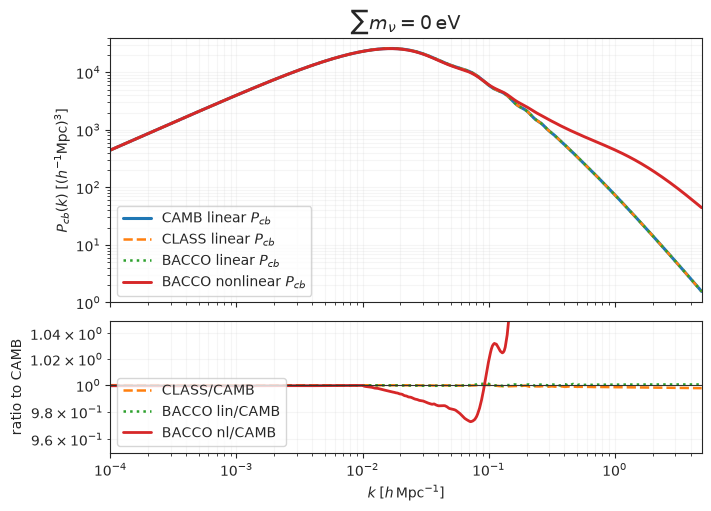

In [11]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS / P_camb_cb_grid, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_ref / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="BACCO lin/CAMB")
axr.semilogx(k_h, pk_nl_ref / P_camb_cb_grid, color="C3", lw=2.0, label="BACCO nl/CAMB")
#axr.semilogx(k_h, Pcb_EB / P_camb_cb_grid, color="C4", lw=2.0, label="DISCOEB nl/CAMB")
axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3)
axr.grid(True, which="both", alpha=0.18)

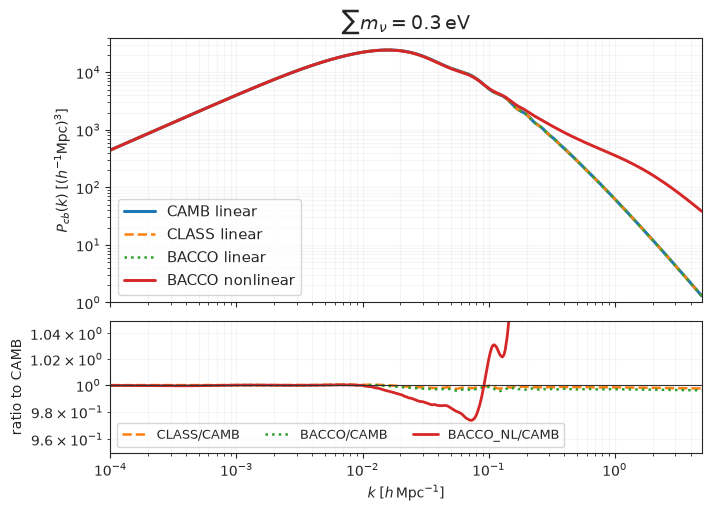

In [12]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear")
#ax.loglog(k_h, Pcb_EB_nu, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(loc=3,prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {cosmo["sum_mnu"]}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pkbc_CLASS_nu / P_camb_cb_grid_nu, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, pk_lin / P_camb_cb_grid_nu, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")
axr.semilogx(k_h, pk_nl / P_camb_cb_grid_nu, color="C3", lw=2.0, label="BACCO_NL/CAMB")
#axr.semilogx(k_h, Pcb_EB_nu / P_camb_cb_grid_nu, color="C4", lw=2.0, label="DISCOEB nl/CAMB")
axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_ref.pgf')

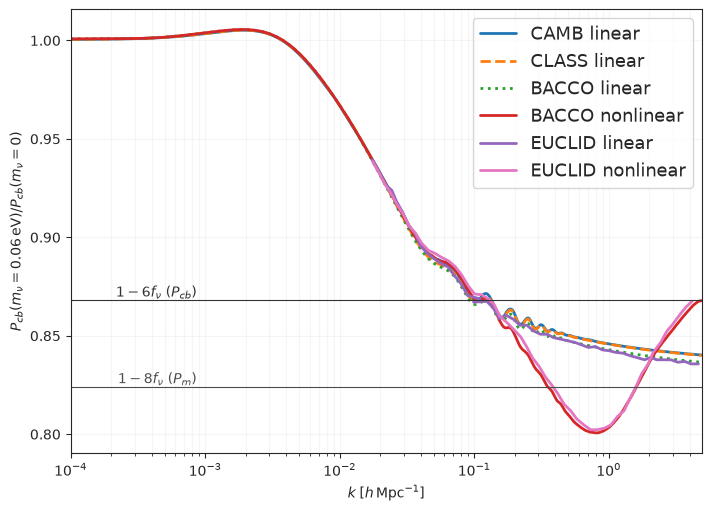

BACCO: 0.8365061450000841
CLASS: 0.8400203601520911
0.003702259342062586


In [13]:
fig, ax = plt.subplots(
    figsize=(7, 5),
    constrained_layout=True,
)

# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=2,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=2,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=2,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2,label="BACCO nonlinear",)

ax.semilogx(euclid[0],euclid[1],color="C4",lw=2,label="EUCLID linear",)
ax.semilogx(euclid_nl[0],euclid_nl[1],color="C6",lw=2,label="EUCLID nonlinear",)

#ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu=0.06\,{\rm eV}) / P_{cb}(m_\nu=0)$"
)

#ax.set_title(rf"Suppression due to $\sum m_\nu = {cosmo["sum_mnu"]}eV $")

ax.legend(prop={'size': 13})
ax.grid(True, which="both", alpha=0.18)

plt.show()
#plt.savefig('supp_ref_006.pgf')

print("BACCO:",ratio_bacco[-1])
print("CLASS:",ratio_class[-1])
print(ratio_camb[-1]-ratio_bacco[-1])

# N-body DISCODJ

## Linear Suppresion

In [14]:
# Set the parameters
name = "3D_analysis"
dim = 3
precision = "single"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 4000  # in Mpc/h
res = 256  # the particles live on a Lagrangrian grid of resolution (res)^dim

results_disco = []

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=omega_cdm,  # cold dark matter content
             Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=sigma8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = mnu_massless) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_massless_z{z}_BACCO.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 3
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)


numsteps = 10  # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_end = a
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim = dj.get_delta_from_pos(X_sim, res= dj.res, n_resample=n_resample)
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=worder)
results_disco.append({
        "k": k,
        "Pcb": Pk,
        "mass": 0,
        "method": "DISCODJ",
        "a": a_end                                                               
    }) 

###########################################################################################################################################################################

cosmo_nu = dict(Omega_c=omega_cdm,  # cold dark matter content
            Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
            h=h,  # dimensionless Hubble constant
            n_s=n_s,  # scalar spectral index
            sigma8=sigma8_nu_cb,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
            mnu = mnu_deg) #Neutrino mass (eV)
dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj_nu)
dj_nu = dj_nu.with_timetables()
dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_massless_z{z}_BACCO.txt")  
dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

numsteps = 10  # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)
dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= dj.res, n_resample=n_resample)
k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=worder)
results_disco.append({
    "k": k,
    "Pcb": Pk_nu,
    "mass": sum_mnu,
    "method": "DISCODJ",
    "a": a_end                                                               
})  
np.save("discodj_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 4000.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
Cosmology(Omega_c=0.26998454332351685, Omega_b=0.04899999871850014, h=0.6700000166893005, sigma8=0.8513803482055664, n_s=0.961899995803833, Omega_k=0.0, w0=-1.0, wa=0.0, mnu=[0. 0. 0.],dtype_num=32, requires_jacfwd=False, is_derivative=False)
sigma8 according to file: 0.8509, sigma8 according to cosmology: 0.8514. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 4000.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
Cosmology(Omega_c=0.26998454332351685, Omega_b=0.04899999871850014, h=0.6700000166893005, sigma8=0.8058578968048096, n_s=0.961899995803833, Omega_k=0.0, w0=-1.0, wa=0.0, mnu=[0.1 0.1 0.1],dtype_num=32, requires_jacfwd=False, is_derivative=False)
sigma8 according to file: 0.8509, sigma8 according to cosmology: 0.8059. The value of sigma8 will

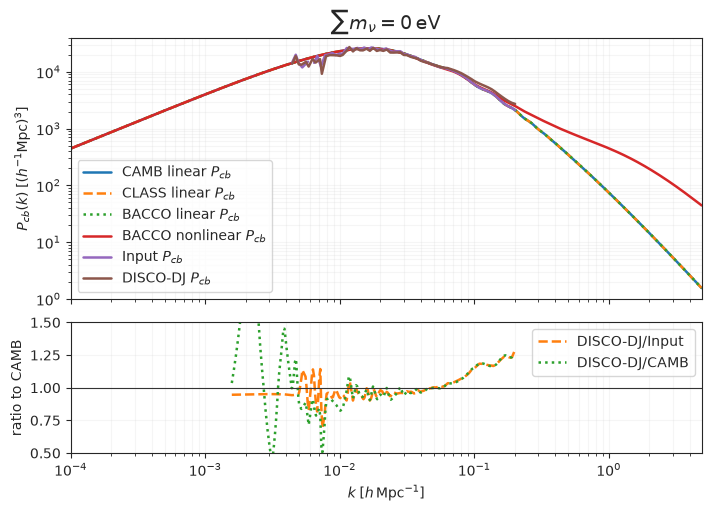

In [15]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], a)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre), np.log(Pk_pre), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=1.8, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre, Pk_pre, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entry0["k"], entry0["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pk / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="DISCO-DJ/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.5,1.5)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

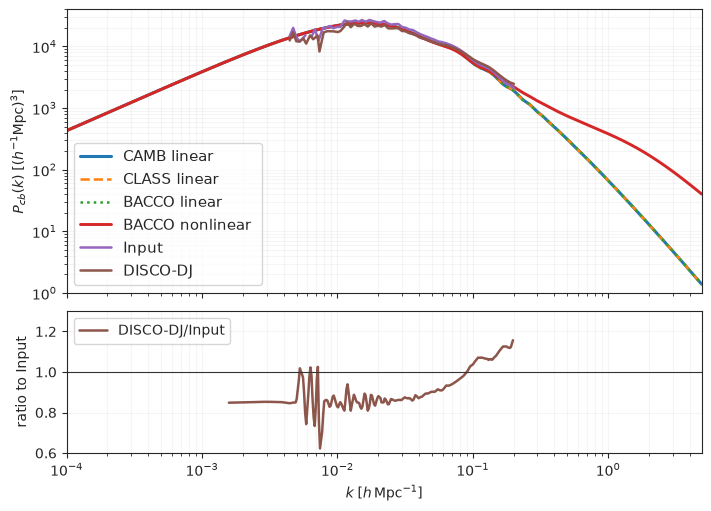

In [16]:
discodj_data = list(np.load("discodj_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], a)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu), np.log(Pk_pre_nu), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid_nu_m, color="C0", lw=2.2, label=r"CAMB linear")
ax.loglog(k_h, Pkbc_CLASS_nu_m, color="C1", lw=1.8, ls="--", label=r"CLASS linear ")
ax.loglog(k_h, pk_lin_m, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl_m, color="C3", lw=2.1, label=r"BACCO nonlinear ")
ax.loglog(k_pre_nu, Pk_pre_nu, color="C4", lw=1.8, label=r"Input ")
ax.loglog(entrym["k"], entrym["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ ")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
#ax.set_title(rf"$\sum m_\nu = {sum_mnu}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, Pk_nu / Pk_in, color="C5", lw=1.8, label="DISCO-DJ/Input")
#axr.semilogx(k_h, Pk_nu / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="DISCO-DJ/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to Input")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.6,1.3)
axr.legend(loc=2,prop={'size': 10})
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_lin.pgf')

/tmp/ipykernel_10461/3616504829.py:88: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axr.set_ylim(1e-4,0)


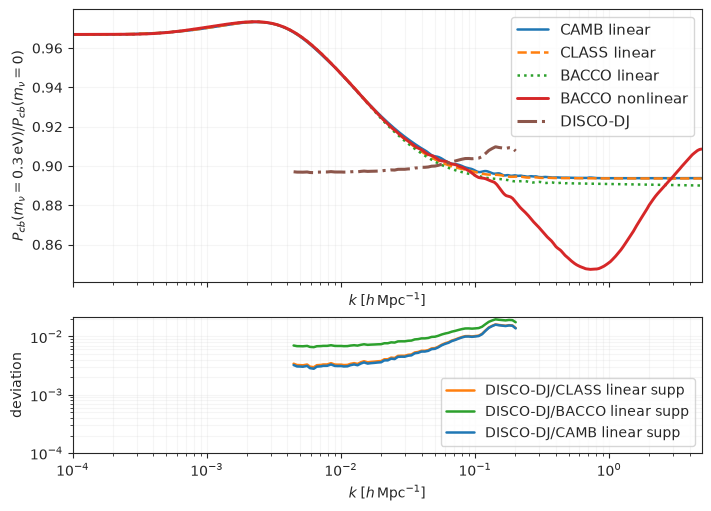

In [17]:
discodj_data = np.load("discodj_results.npy", allow_pickle=True)
discodj_data = [d for d in discodj_data if np.isclose(d["a"], a_end)]
entries = [d for d in discodj_data if np.isclose(d["a"], a_end)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
k = entry0["k"]
Pk = entry0["Pcb"]
Pk_nu = entrym["Pcb"]

fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu_m / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu_m     / Pkbc_CLASS
ratio_bacco    = pk_lin_m            / pk_ref
ratio_bacco_nl = pk_nl_m             / pk_nl_ref
ratio_disco_dj = Pk_nu             / Pk
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=1.8,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)
ax.semilogx(k,ratio_disco_dj,color="C5", linestyle='-.',lw=2.2,label="DISCO-DJ",)

#ax.semilogx(euclid[0],euclid[1],color="C4",lw=2,label="EUCLID linear",)
#ax.semilogx(euclid_nl[0],euclid_nl[1],color="C6",lw=2,label="EUCLID nonlinear",)

# ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

class_supp = ratio_class[-1]
camb_supp = ratio_camb[-1]
bacco_supp = ratio_bacco[-1]
#ax.axhline(supp_Pcb, color="0.2", lw=0.8)
#ax.axhline(supp_P,   color="0.3", lw=0.8)
#
#ax.annotate(
#    r"$1-6f_\nu$ ($P_{cb}$)",
#    xy=(0.2, supp_Pcb),
#    xycoords=("axes fraction", "data"),
#    ha="right",
#    va="bottom",
#    color="0.2",
#)
#
#ax.annotate(
#    r"$1-8f_\nu$ ($P_m$)",
#    xy=(0.2, supp_P),
#    xycoords=("axes fraction", "data"),
#    ha="right",
#    va="bottom",
#    color="0.3",
#)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu=0.3\,{\rm eV}) / P_{cb}(m_\nu=0)$"
)

#ax.set_title(r"Suppression due to $\sum m_\nu $")

ax.legend(prop={'size': 11},loc=1)
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k, abs(ratio_disco_dj-class_supp), color="C1", lw=1.8, label="DISCO-DJ/CLASS linear supp")
axr.semilogx(k, abs(ratio_disco_dj-bacco_supp), color="C2", lw=1.8, label="DISCO-DJ/BACCO linear supp")
axr.semilogx(k, abs(ratio_disco_dj-camb_supp), color="C0", lw=1.8, label="DISCO-DJ/CAMB linear supp")



axr.axhline(0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("deviation")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_yscale("log")
axr.set_ylim(1e-4,0)
axr.legend(prop={'size': 10},loc=4)
axr.grid(True, which="both", alpha=0.18)

plt.show()
#plt.savefig('supp_lin.pgf')

## Non-linear Suppresion (Scale dep)

In [18]:
# Set the parameters
name = "3D_analysis"
dim = 3
precision = "single"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 512  # in Mpc/h
res = 256  # the particles live on a Lagrangrian grid of resolution (res)^dim

results_disco = []

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=omega_cdm,  # cold dark matter content
             Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=h,  # dimensionless Hubble constant
             n_s=n_s,  # scalar spectral index
             sigma8=sigma8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = mnu_massless) #Neutrino mass (eV)

dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
print(dj)
dj = dj.with_timetables()
dj = dj.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_massless_z{z}_CLASS.txt")
white_noise_field = dj.get_ngenic_noise(seed=13)  # a white noise field, defined in real space
dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nl, Pk_pre_nl, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

n_order = 2
stepper = "bullfrog"
method = "pm"
res_pm = dj.res
time_var = "D"
antialias = 1
grad_kernel_order = 0
laplace_kernel_order = 0
worder = 3
n_resample = 1
deconvolve = True
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)

numsteps = 40 # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_end = a
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)

dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim = dj.get_delta_from_pos(X_sim, res= 2*dj.res, n_resample=n_resample, antialias=1)
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=deconvolve, worder=worder)
results_disco.append({
        "k": k,
        "Pcb": Pk,
        "mass": 0,
        "method": "DISCODJ",
        "a": a_end                                                               
    }) 

###########################################################################################################################################################################



cosmo_nu = dict(Omega_c=omega_cdm_nu,  # cold dark matter content
            Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
            h=h,  # dimensionless Hubble constant
            n_s=n_s,  # scalar spectral index
            sigma8=sigma8_nu,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
            mnu = mnu_deg) #Neutrino mass (eV)
dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj_nu)
dj_nu = dj_nu.with_timetables()
dj_nu = dj_nu.with_linear_ps(fix_sigma8=True, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z{z}_CLASS.txt")
dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
k_pre_nu_nl, Pk_pre_nu_nl, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

# initial scale factor of the simulation (where it is initialized with LPT)
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)
dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= 2*dj.res, n_resample=n_resample, antialias=1)
k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=deconvolve, worder=worder)
results_disco.append({
    "k": k,
    "Pcb": Pk_nu,
    "mass": sum_mnu,
    "method": "DISCODJ",
    "a": a_end                                                               
})  

np.save("discodj_nl_results.npy", results_disco)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 512.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
Cosmology(Omega_c=0.26998454332351685, Omega_b=0.04899999871850014, h=0.6700000166893005, sigma8=0.8513803482055664, n_s=0.961899995803833, Omega_k=0.0, w0=-1.0, wa=0.0, mnu=[0. 0. 0.],dtype_num=32, requires_jacfwd=False, is_derivative=False)
sigma8 according to file: 0.8506, sigma8 according to cosmology: 0.8514. The value of sigma8 will be normalized to the cosmology.
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 512.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
Cosmology(Omega_c=0.26280930638313293, Omega_b=0.04899999871850014, h=0.6700000166893005, sigma8=0.7912275791168213, n_s=0.961899995803833, Omega_k=0.0, w0=-1.0, wa=0.0, mnu=[0.1 0.1 0.1],dtype_num=32, requires_jacfwd=False, is_derivative=False)
sigma8 according to file: 0.7910, sigma8 according to cosmology: 0.7912. The value of sigma8 will b

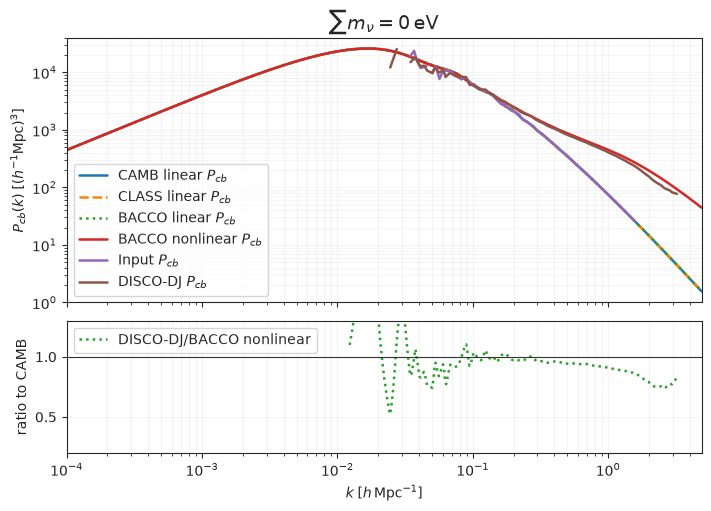

In [19]:
discodj_data = list(np.load("discodj_nl_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], a)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nl), np.log(Pk_pre_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=1.8, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=1.8, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre_nl, Pk_pre_nl, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entry0["k"], entry0["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

#axr.semilogx(k_h, Pk / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk / pk_nl_ref , color="C2", lw=1.8, ls=":", label="DISCO-DJ/BACCO nonlinear")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.2,1.3)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

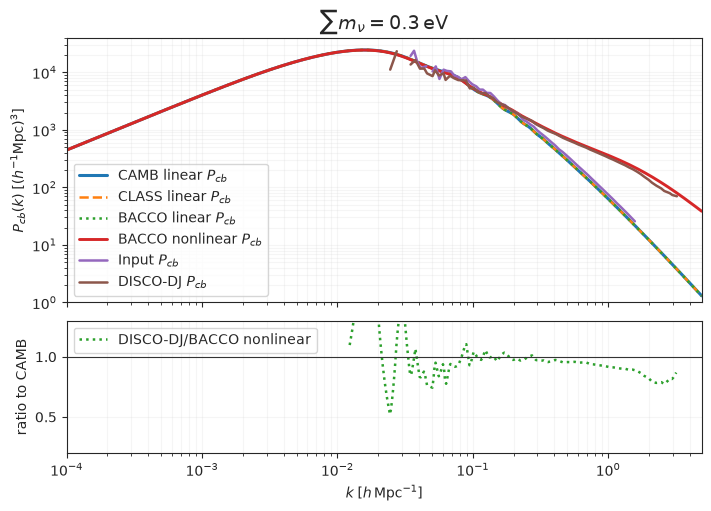

In [20]:
discodj_data = list(np.load("discodj_nl_results.npy", allow_pickle=True))
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

entries = [d for d in discodj_data if np.isclose(d["a"], a)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu_nl), np.log(Pk_pre_nu_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


ax.loglog(k_h, P_camb_cb_grid_nu, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")
ax.loglog(k_pre_nu_nl, Pk_pre_nu_nl, color="C4", lw=1.8, label=r"Input $P_{cb}$")
ax.loglog(entrym["k"], entrym["Pcb"], color="C5", lw=1.8, label=r"DISCO-DJ $P_{cb}$")
#ax.loglog(k_h, Pcb_EB, color="C4", lw=2.1, label=r"DISCOEB linear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {sum_mnu}\,\mathrm{{eV}}$",fontsize=14)

#axr.semilogx(k_h, Pk_nu / Pk_in, color="C1", lw=1.8, ls="--", label="DISCO-DJ/Input")
axr.semilogx(k_h, Pk_nu / pk_nl, color="C2", lw=1.8, ls=":", label="DISCO-DJ/BACCO nonlinear")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())

axr.set_ylim(0.2,1.3)
axr.legend()
axr.grid(True, which="both", alpha=0.18)

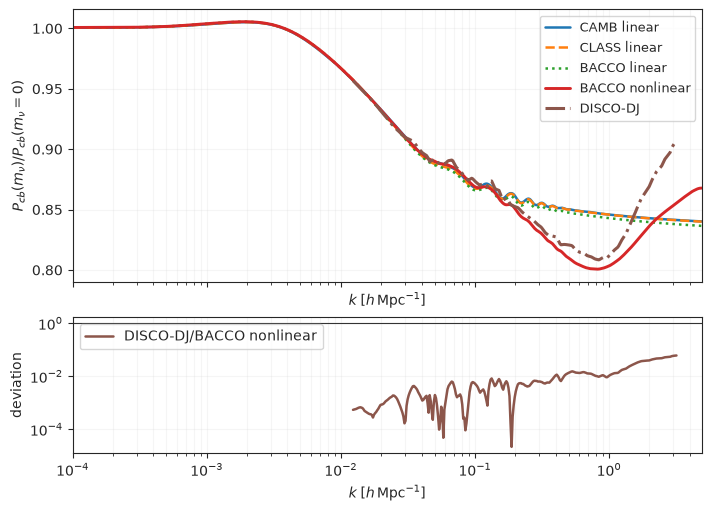

In [23]:
entries = [d for d in discodj_data if np.isclose(d["a"], a)]
entry0 = next(d for d in entries if np.isclose(d["mass"], 0.0))
entrym = next(d for d in entries if not np.isclose(d["mass"], 0.0))
Pk = np.exp(interp1d(np.log(entry0["k"]), np.log(entry0["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
Pk_nu =  np.exp(interp1d(np.log(entrym["k"]), np.log(entrym["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

Pk_in = np.exp(interp1d(np.log(k_pre_nu_nl), np.log(Pk_pre_nu_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
# Ratios massive / massless
ratio_camb     = P_camb_cb_grid_nu / P_camb_cb_grid
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref
ratio_dj       = Pk_nu/Pk
# ratio_disco = Pcb_EB_nu / Pcb_EB

ax.semilogx(k_h,ratio_camb,color="C0",lw=1.8,label="CAMB linear",)
ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)
ax.semilogx(k_h,ratio_dj,color="C5", linestyle='-.',lw=2.2,label="DISCO-DJ",)

#ax.semilogx(euclid[0],euclid[1],color="C4",lw=2,label="EUCLID linear",)
#ax.semilogx(euclid_nl[0],euclid_nl[1],color="C6",lw=2,label="EUCLID nonlinear",)

# ax.semilogx(k_h, ratio_disco, color="C4", lw=2.1, label="DISCOEB")

#ax.axhline(supp_Pcb, color="0.2", lw=0.8)
#ax.axhline(supp_P,   color="0.3", lw=0.8)
#
#ax.annotate(
#    r"$1-6f_\nu$ ($P_{cb}$)",
#    xy=(0.2, supp_Pcb),
#    xycoords=("axes fraction", "data"),
#    ha="right",
#    va="bottom",
#    color="0.2",
#)
#
#ax.annotate(
#    r"$1-8f_\nu$ ($P_m$)",
#    xy=(0.2, supp_P),
#    xycoords=("axes fraction", "data"),
#    ha="right",
#    va="bottom",
#    color="0.3",
#)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu) / P_{cb}(m_\nu=0)$"
)

#ax.set_title(rf"Suppression due to $\sum m_\nu , L=500 Mpc$")

ax.legend(prop={'size': 9})
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k_h, abs(ratio_dj /  ratio_bacco_nl-1), color="C5", lw=1.8, label="DISCO-DJ/BACCO nonlinear")


axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("deviation")
axr.set_xlim(k_h.min(), k_h.max())

#axr.set_ylim(0.97,1.03)
axr.set_yscale("log")
axr.legend(prop={'size': 10},loc=2)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('supp_nl.pgf')

# Neutrino hierachy test

In [22]:
## FIX m_nu to 0.1eV to see differences btw hierarchies 

mnu_massless = [0,0,0]
mnu_deg = [0.1/3,0.1/3,0.1/3] # Array of neutrinos masses for degenerarte case 
m1,m2,m3 = get_masses(2.45e-3,7.50e-5,0.1,'NH')
mnu_NH =[m1,m2,m3]
m1,m2,m3 = get_masses(2.45e-3,7.50e-5,0.1,'IH')
mnu_IH = [m1,m2,m3]

# Set the parameters
name = "3D_analysis"
dim = 3
precision = "single"
if precision == "double":
    config.update("jax_enable_x64", True)

# Define the boxsize and resolution
boxsize = 4000  # in Mpc/h
res = 256  # the particles live on a Lagrangrian grid of resolution (res)^dim

results_disco = []


for m in masses : 
    cosmo_nu = dict(Omega_c=omega_cdm,  # cold dark matter content
                Omega_b=omega_b,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                h=h,  # dimensionless Hubble constant
                n_s=n_s,  # scalar spectral index
                sigma8=sigma8,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                mnu = m) #Neutrino mass (eV)
                
    dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
    print(dj_nu)

    n_order = 2
    stepper = "bullfrog"
    method = "pm"
    res_pm = dj_nu.res
    time_var = "D"
    antialias = 0
    grad_kernel_order = 4
    laplace_kernel_order = 0
    worder = 3
    n_resample = 1
    deconvolve = True
    nlpt_order_ics = n_order
    chunk_size = None  

    dj_nu = dj_nu.with_timetables()
    if m==mnu_deg :
        dj_nu = dj_nu.with_linear_ps(fix_sigma8=False, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z{z}_CLASS.txt")
    elif m==mnu_NH : 
        dj_nu = dj_nu.with_linear_ps(fix_sigma8=False, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z{z}_NH_CLASS.txt")
    else :
        dj_nu = dj_nu.with_linear_ps(fix_sigma8=False, transfer_function="from_file", filename=f"Pk_cb_sumMnu_{sum_mnu:.2f}eV_z{z}_IH_CLASS.txt")
    white_noise_field = dj_nu.get_ngenic_noise(seed=13)
    dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
    k_pre_nu_nl, Pk_pre_nu_nl, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)

    numsteps = 10  # number of steps to be performed
    a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
    a_list = np.linspace(a_ini, a_end, numsteps, endpoint=True)
    dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
    X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                    time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                    grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                    nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                    deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                    convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT
    delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res= 2*dj.res, n_resample=n_resample,antialias=1)
    k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=deconvolve, worder=worder)
    if m == mnu_deg : 
        results_disco.append({
            "k": k,
            "Pcb": Pk_nu,
            "mass": 0,                                                              
        })  
    elif m == mnu_NH : 
        results_disco.append({
            "k": k,
            "Pcb": Pk_nu,
            "mass": 1,                                                              
        })    
    else :         
        results_disco.append({
            "k": k,
            "Pcb": Pk_nu,
            "mass": 2,                                                              
        })    


np.save("discodj_hierarchy_results.npy", results_disco)


DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 256³ particles
Boxsize: 4000.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
Cosmology(Omega_c=0.26998454332351685, Omega_b=0.04899999871850014, h=0.6700000166893005, sigma8=0.8513803482055664, n_s=0.961899995803833, Omega_k=0.0, w0=-1.0, wa=0.0, mnu=[0.1 0.1 0.1],dtype_num=32, requires_jacfwd=False, is_derivative=False)


KeyboardInterrupt: 

In [ ]:
results_disco = list(np.load("discodj_hierarchy_results.npy", allow_pickle=True))
entry_deg = next(d for d in results_disco if d["mass"] == 0)  
entry_NH = next(d for d in results_disco if d["mass"] == 1) 
entry_IH = next(d for d in results_disco if d["mass"] == 2)  
Pk_deg =  np.exp(interp1d(np.log(entry_deg["k"]), np.log(entry_deg["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_nu)))
Pk_NH =  np.exp(interp1d(np.log(entry_NH["k"]), np.log(entry_NH["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_nu)))
Pk_IH =  np.exp(interp1d(np.log(entry_IH["k"]), np.log(entry_IH["Pcb"]), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_nu)))

fig, ax = plt.subplots(
    figsize=(7, 5),
    constrained_layout=True,
)

ax.semilogx(k_nu,  1-Pk_NH / Pk_deg, color="C1", lw=2, ls=":", label="Normal/Degenerate")
ax.semilogx(k_nu, 1-Pk_IH / Pk_deg, color="C2", lw=2, ls=":", label="Inverted/Degenerate")
ax.semilogx(k_nu, 1-Pk_NH / Pk_IH, color="C3", lw=2, label="Normal/Inverted")

ax.set_title(rf"$\sum m_\nu = 0.1\,\mathrm{{eV}}$",fontsize=14)
ax.set_ylabel(r"$1 - P_{cb}^i(k)/P_{cb}^j(k)$")
ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
#axr.set_xlim(k_nu.min(), k_nu.max())

#ax.set_ylim(-0.0015,0.0015)
ax.legend(prop={'size': 12},loc=2)
ax.grid(True, which="both", alpha=0.18)

plt.show()

#plt.savefig('hierarchy.pgf')

StopIteration: 